In [22]:
from collections.abc import Callable

from consensus_imports.elo_predict import elo_predict
from consensus_imports.mc_predict import mc_predict

"""
Models is a list of tuples containing a model function (outputs a win probability given a home and away team) and a win rate.
Fill with any given set of models.
"""
models: list[tuple[Callable[[str, str], float], float]] = [
    (elo_predict, 0.6106),
    #(mc_predict, 0.544)
]
total_win_rate: float = sum(map(lambda model: model[1], models))

In [23]:
def predict(home: str, away: str) -> float:
    """
    :param home: Home team in a given game.
    :param away: Away team in a given game.
    :return:     Weighted average (according to win rates) probability of all models' odds for the home team to win.
    """
    return sum(map(lambda model: model[0](home, away) * model[1], models))/total_win_rate

In [24]:
def kelly_criterion(probability: float, odds: float = 2.0, fraction: float = 1.0) -> float:
    """
    :param probability: The win probability.
    :param odds: Given odds for the team to win. By default, we consider the odds to be even (for backtesting).
    :param fraction: What fraction of the Kelly formula's output to bet.
    :return: The percentage of the account to bet. With even odds, this is 2p - 1.
    """
    return fraction * (probability - (1 - probability) / (odds - 1))

In [25]:
from pandas import DataFrame, Series
import pandas as pd

data: DataFrame = pd.read_csv("data/nba_team_reference.csv")
data = data[int(len(data) * 0.9):]
data["points_ratio"] = data["pts_home"] / (data["pts_home"] + data["pts_away"]) # Tells us which team won and by how much (ratio < 0.5 means home team lost).
data.drop(columns=["season_year", "team_id_home", "team_id_away", "pts_home", "pts_away", "home_win"], inplace=True) # Formatting the data...
data.rename(columns={"game_id": "id", "game_date": "date", "team_abbreviation_home": "home", "team_abbreviation_away": "away"}, inplace=True)

In [26]:
# Calculate expected outcomes and percentage of account to bet for each test game, as well as whether or not the prediction was correct.
data["prob"] = data.apply(lambda row: predict(row["home"], row["away"]), axis=1)
data.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
data["kelly_bet"] = data.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"]), fraction=0.25), axis=1)
data["correct"] = (data["points_ratio"] > 0.5) == (data["prob"] > 0.5)

#  Calculate account balance at each time step.
balances: list[float] = [ 10_000.0 ]
for row in data.itertuples():
    balances.append(balances[-1] + balances[-1] * row.kelly_bet * (1 if row.correct else -1))

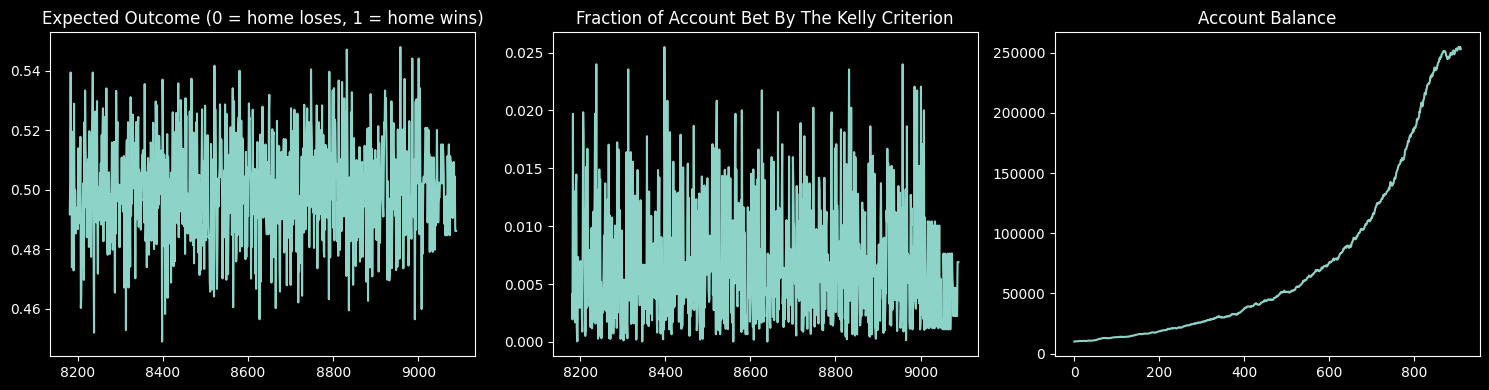

In [27]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(data.prob)
axs[0].set_title("Expected Outcome (0 = home loses, 1 = home wins)")

axs[1].plot(data.kelly_bet)
axs[1].set_title("Fraction of Account Bet By The Kelly Criterion")

axs[2].plot(balances)
axs[2].set_title("Account Balance")

plt.tight_layout()
plt.show()

In [28]:
# Calculate win rate and final balance.
success: dict[bool, int]   = data["correct"].value_counts().to_dict()
win_rate: float            = 100 * success[True] / (success[True] + success[False])
ret: float                 = balances[-1] - balances[0]
returns: float             = ret / balances[0]
series: Series             = Series(balances).pct_change()
avg_ret: float             = series.mean() * 100
stddev_ret: float          = series.std() * 100
stddev_downside_ret: float = Series(filter(lambda ret: ret < 0, series)).std() * 100
kurtosis_ret: float        = series.kurtosis()

max_drawdown: tuple[int, float] = (0, 0)
for i in range(len(balances)):
    for j in range(i + 1, len(balances)):
        diff: float = (balances[j] - balances[i]) / balances[i]

        if diff < max_drawdown[1]:
            max_drawdown = (j - i, diff)

sharpe_ratio: float  = avg_ret / stddev_ret
sortino_ratio: float = avg_ret / stddev_downside_ret
calmar_ratio: float  = returns / -max_drawdown[1]

print(f"Win Rate: {round(win_rate, 2)}%")
print(f"Total Return: {round(ret, 2)} ({round(100 * returns, 2)}%)")
print(f"Mean Bet-To-Bet Return: {round(avg_ret, 2)}%")
print(f"Volatility (standard deviation) of Bet-To-Bet Returns: {round(stddev_ret, 2)}%")
print(f"Downside Volatility of Returns: {round(stddev_downside_ret, 2)}%")
print(f"Kurtosis of Returns: {round(kurtosis_ret, 2)}")
print(f"Maximum Drawdown: {round(max_drawdown[1] * 100, 2)}% over {max_drawdown[0]} games")
print(f"Sharpe Ratio: {sharpe_ratio}")
print(f"Sortino Ratio: {sortino_ratio}")
print(f"Calmar Ratio: {calmar_ratio}")

Win Rate: 68.87%
Total Return: 242995.5 (2429.96%)
Mean Bet-To-Bet Return: 0.36%
Volatility (standard deviation) of Bet-To-Bet Returns: 0.76%
Downside Volatility of Returns: 0.42%
Kurtosis of Returns: 0.06
Maximum Drawdown: -4.12% over 12 games
Sharpe Ratio: 0.4718583338389793
Sortino Ratio: 0.8645155802691067
Calmar Ratio: 589.4121208223298
